# Step-by-step Sentinel-2 extraction 

This notebook runs the full AEREO pipeline — **Search**, **Prepare** and **Extract** — step by step. 
We query a STAC catalog for Sentinel-2 assets, build extraction tasks for the AOI grid, and run each task through read → reproject → write.

Each of these functions can be replaced by ANY function that conforms to the inputs and outputs of each step as follows:

| Step | Input | Output |
|------|-------|--------|
| Search | `(collections, intersects, start_datetime, end_datetime, **kwargs)` | `GeoDataFrame[AssetSchema]` |
| Build | `(GeoDataFrame[AssetSchema], ExtractionJob)` | `Sequence[ExtractionTask]` |
| Read | `ExtractionTask` | `xr.Dataset` |
| Preprocess (optional) | `xr.Dataset` | `xr.Dataset` |
| Reproject | `(xr.Dataset, ExtractionTask, **kwargs)` | `dict[str, xr.Dataset]` |
| Postprocess (optional) | `xr.Dataset` | `xr.Dataset` |
| Write | `(xr.Dataset, ExtractionTask, ExtractionPatch)` | `GeoDataFrame[ArtifactSchema]` |

# Configuring AOI, Grid, Patch and Extraction pipeline
Before we start, we must configure our `ExtractionJob`. 
This means defining the `grid` to use, the `patch` resolution we want (e.g. 10 m, 100 m), and the functions to use in the `extraction pipeline` — always conforming to the required inputs and outputs.

If we know all of this beforehand, we can run our pipeline anywhere by serializing the job, and define different pipelines using only config files!

![AEREO config interaction diagram](assets/aereo_configs.svg)


In [1]:
from aereo.builtins.search import search_stac
from datetime import datetime, timezone
from shapely.geometry import Polygon

from aereo.pipeline import ExtractionJob
from aereo.interfaces import ExtractConfig, GridConfig, PatchConfig
from aereo.builtins import read_odc_stac, reproject_odc, write_geotiff

# AOI polygon — Chocón reservoir, Argentina (inlined so the notebook has no file dependencies).
aoi_polygon = Polygon(
    [
        (-68.90986824592407, -39.23705421799603),
        (-68.65925870907353, -39.23705421799603),
        (-68.65925870907353, -39.41589522092947),
        (-68.90986824592407, -39.41589522092947),
        (-68.90986824592407, -39.23705421799603),
    ]
)

grid_config = GridConfig(
    target_grid_dist=10_000,
)

patch_config = PatchConfig(
    resolution=10.0,
    margin=10.0,
)

extract_config = ExtractConfig(
    read=read_odc_stac,
    preprocess=[],
    reproject=reproject_odc,
    postprocess=[],
    write=write_geotiff,
)

job = ExtractionJob(
    name="sentinel2_sample",
    grid_config=grid_config,
    patch_config=patch_config,
    output_uri="/tmp/aereo_extraction",
    extract=extract_config,
    target_aoi=aoi_polygon,
)

## Step 1 — Search: `search_stac`

The search provider queries the STAC API and returns a GeoDataFrame of matched assets. Each row corresponds to one requested asset (e.g. `red`, `nir`) from one STAC item. All parameters are passed explicitly.


In [2]:
assets = search_stac(
    stac_api_url="https://earth-search.aws.element84.com/v1",
    collections={"sentinel-2-l2a": ["red", "nir"]},
    intersects=aoi_polygon,
    start_datetime=datetime(2024, 1, 1, tzinfo=timezone.utc),
    end_datetime=datetime(2024, 1, 10, tzinfo=timezone.utc),
)

print(f"\u2713 Found {len(assets)} asset rows")
print("Columns:", list(assets.columns))
print("First rows:")
assets[["id", "collection", "channel_id", "crs", "href"]].head()

✓ Found 12 asset rows
Columns: ['id', 'collection', 'geometry', 'start_time', 'end_time', 'href', 'channel_id', 'crs', 'stac_item']
First rows:


,id,collection,channel_id,crs,href
0,S2A_19HDS_20240107_0_L2A_red,sentinel-2-l2a,red,EPSG:32719,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
1,S2A_19HDS_20240107_0_L2A_nir,sentinel-2-l2a,nir,EPSG:32719,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
2,S2A_19HES_20240107_0_L2A_red,sentinel-2-l2a,red,EPSG:32719,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
3,S2A_19HES_20240107_0_L2A_nir,sentinel-2-l2a,nir,EPSG:32719,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
4,S2B_19HDS_20240105_0_L2A_red,sentinel-2-l2a,red,EPSG:32719,https://sentinel-cogs.s3.us-west-2.amazonaws.c...


## Step 2 — Build tasks: `build_grouped_tasks`

The task builder takes the search-result GeoDataFrame and the `ExtractionJob` and produces a list of `ExtractionTask` objects. Tasks are grouped by start time and native CRS, and patches are chunked by `cells_per_task`.


In [3]:
from aereo.builtins.task_builder import build_grouped_tasks

tasks = build_grouped_tasks(
    search_results=assets,
    job=job,
    cells_per_task=4,
)

print(f"\u2713 Built {len(tasks)} extraction task(s)")
for i, task in enumerate(tasks):
    print(f"Task {i}: {task}")

✓ Built 12 extraction task(s)
Task 0: ExtractionTask(n_assets=2, extract_len=3, patches=ExtractionPatch('ExtractionPatch(id='439D_593L', d=10000, cell_geometry=<POLYGON ((-68.837 -39.431, -68.837 -39.341, -68.953 -39.341, -68.953 -39.43...>, resolution=10.0, margin=10.0, padding=0, conform_to=None), ExtractionPatch(id='439D_592L', d=10000, cell_geometry=<POLYGON ((-68.721 -39.431, -68.721 -39.341, -68.837 -39.341, -68.837 -39.43...>, resolution=10.0, margin=10.0, padding=0, conform_to=None), ExtractionPatch(id='439D_591L', d=10000, cell_geometry=<POLYGON ((-68.605 -39.431, -68.605 -39.341, -68.721 -39.341, -68.721 -39.43...>, resolution=10.0, margin=10.0, padding=0, conform_to=None), ExtractionPatch(id='438D_594L', d=10000, cell_geometry=<POLYGON ((-68.865 -39.341, -68.865 -39.251, -68.981 -39.251, -68.981 -39.34...>, resolution=10.0, margin=10.0, padding=0, conform_to=None)'), output_uri='/tmp/aereo_extraction')
Task 1: ExtractionTask(n_assets=2, extract_len=3, patches=ExtractionPatch

In [4]:
# Inspect the first task in detail
task = tasks[0]

print("Task context:", dict(task.task_context))
print(f"Number of asset rows in task: {len(task.assets)}")
print(f"Number of patches in task: {len(task.patches)}")

patch = task.patches[0]
print(f"First patch id: {patch.id}")
print(f"Patch resolution: {patch.resolution} m")
print(f"Patch UTM CRS: {patch.utm_crs}")
print(f"Patch geobox shape: {patch.geobox.shape}")

# Extraction stages available on the task (delegated from job.extract)
print("Extraction stages:")
print("  read:", task.extract.read.__name__)
print(
    "  preprocess:", [getattr(p, "__name__", str(p)) for p in task.extract.preprocess]
)
print("  reproject:", task.extract.reproject.__name__)
print(
    "  postprocess:", [getattr(p, "__name__", str(p)) for p in task.extract.postprocess]
)
print("  write:", task.extract.write.__name__)

Task context: {'job_id': 'sentinel2_sample', 'chunk_id': 0, 'total_chunks': 12, 'start_time': '2024-01-02 14:33:47.691000', 'crs': 'EPSG:32719', 'init_params': {}}
Number of asset rows in task: 2
Number of patches in task: 4
First patch id: 439D_593L
Patch resolution: 10.0 m
Patch UTM CRS: 32719
Patch geobox shape: Shape2d(x=1100, y=1100)
Extraction stages:
  read: read_odc_stac
  preprocess: []
  reproject: reproject_odc
  postprocess: []
  write: write_geotiff


## Step 3 — Read: `read_odc_stac`

The reader reconstructs `pystac.Item` objects from the `stac_item` column and uses `odc.stac.load` to build a lazy `xarray.Dataset` in the native CRS of the STAC items.


In [5]:
from aereo.builtins.read import read_odc_stac

# Call the reader directly with the task.
ds_native = read_odc_stac(task)

print("Native dataset:")
ds_native

Native dataset:


<xarray.Dataset> Size: 16MB
Dimensions:      (y: 1830, x: 2166, time: 1)
Coordinates:
  * y            (y) float64 15kB 5.655e+06 5.655e+06 ... 5.637e+06 5.637e+06
  * x            (x) float64 17kB 5.078e+05 5.078e+05 ... 5.294e+05 5.294e+05
  * time         (time) datetime64[us] 8B 2024-01-02T14:33:47.691000
    spatial_ref  int32 4B 32719
Data variables:
    red          (time, y, x) uint16 8MB dask.array<chunksize=(1, 1830, 2166), meta=np.ndarray>
    nir          (time, y, x) uint16 8MB dask.array<chunksize=(1, 1830, 2166), meta=np.ndarray>
Attributes:
    start_time:  2024-01-02 14:33:47.691000
    end_time:    2024-01-02 14:33:47.691000

## Step 4 — Reproject: `reproject_odc`

The reprojector warps the native CRS dataset onto each patch's UTM GeoBox. It returns a mapping from `patch.id` to a reprojected `xr.Dataset`.


In [6]:
from aereo.builtins.reproject import reproject_odc

# Call the reprojector directly with explicit parameters.
ds_per_patch = reproject_odc(
    ds=ds_native,
    task=task,
    resampling="nearest",
)

print(f"\u2713 Reprojected dataset available for {len(ds_per_patch)} patch(es)")
print("Patch IDs:", list(ds_per_patch.keys()))

✓ Reprojected dataset available for 4 patch(es)
Patch IDs: ['439D_593L', '439D_592L', '439D_591L', '438D_594L']


## Step 5 — Write: `write_geotiff`

The writer serialises a patch's dataset to a GeoTIFF and returns a GeoDataFrame of written artifacts conforming to `ArtifactSchema`.


In [7]:
from aereo.builtins.write import write_geotiff

# Write a single patch
patch = task.patches[0]
patch_artifacts = write_geotiff(
    ds=ds_per_patch[patch.id],
    task=task,
    patch=patch,
)

print(f"\u2713 Wrote {len(patch_artifacts)} artifact row(s)")
print("Columns:", list(patch_artifacts.columns))
print("Artifact rows:")
patch_artifacts[["id", "uri", "grid_cell", "start_time", "end_time"]]

✓ Wrote 1 artifact row(s)
Columns: ['id', 'source_ids', 'start_time', 'end_time', 'uri', 'collection', 'geometry', 'grid_cell', 'grid_dist', 'cell_geometry', 'cell_utm_crs', 'cell_utm_footprint']
Artifact rows:


,id,uri,grid_cell,start_time,end_time
0,439D_593L_red+nir_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,439D_593L,2024-01-02 14:33:47.691,2024-01-02 14:33:47.691


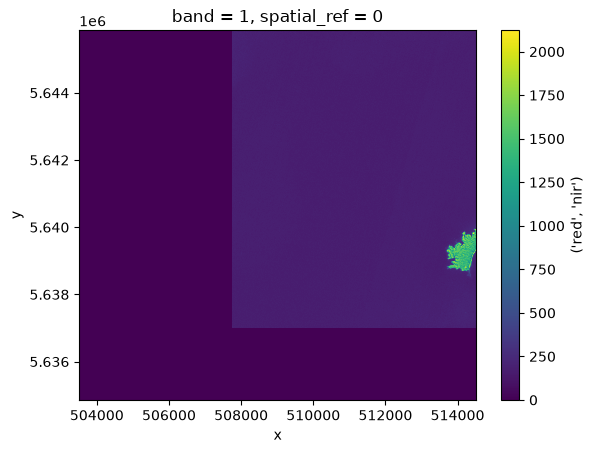

In [8]:
import rioxarray

rioxarray.open_rasterio(patch_artifacts.iloc[0].uri)[0].plot()

## Putting it together: `run_task`

`run_task(task)` executes the read → preprocess → reproject → postprocess → write loop for a single `ExtractionTask`. It is what `LocalExecutor` uses under the hood.


In [9]:
from aereo.execution import run_task

artifacts_gdf = run_task(task)

print(f"\u2713 Single task produced {len(artifacts_gdf)} artifact row(s)")
artifacts_gdf[["id", "uri", "grid_cell", "geometry"]].head()

✓ Single task produced 4 artifact row(s)


,id,uri,grid_cell,geometry
0,439D_593L_red+nir_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,439D_593L,"POLYGON ((514510 5634860, 514510 5645860, 5035..."
1,439D_592L_red+nir_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,439D_592L,"POLYGON ((524530 5634840, 524530 5645840, 5135..."
2,439D_591L_red+nir_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,439D_591L,"POLYGON ((534540 5634810, 534540 5645810, 5235..."
3,438D_594L_red+nir_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,438D_594L,"POLYGON ((512180 5644830, 512180 5655830, 5011..."


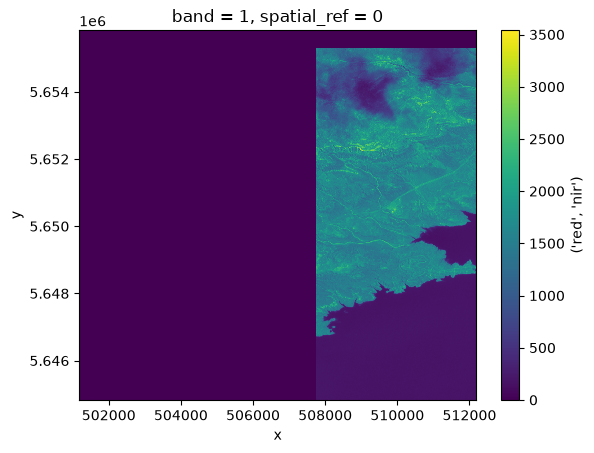

In [10]:
rioxarray.open_rasterio(artifacts_gdf.iloc[3].uri)[0].plot()

## Batch execution with an executor

To run many tasks in parallel, pass the task list to an `Executor`. For COG/I/O-bound extractors like this one, `LocalExecutor(use_threads=True)` is the safer choice in Jupyter and avoids the pickling issues that can make `ProcessPoolExecutor` hang.


In [11]:
from aereo.executors import LocalExecutor

executor = LocalExecutor(workers=4, use_threads=True)
artifacts = executor(tasks)

print(f"\u2713 Extracted {len(artifacts)} artifact row(s) from {len(tasks)} task(s)")
artifacts[["id", "uri", "grid_cell", "start_time"]].head()

/root/repos/aereo/.venv/lib/python3.13/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


✓ Extracted 41 artifact row(s) from 12 task(s)


,id,uri,grid_cell,start_time
0,439D_593L_red+nir_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,439D_593L,2024-01-02 14:33:47.691
1,439D_592L_red+nir_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,439D_592L,2024-01-02 14:33:47.691
2,439D_591L_red+nir_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,439D_591L,2024-01-02 14:33:47.691
3,438D_594L_red+nir_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,438D_594L,2024-01-02 14:33:47.691
4,438D_593L_red+nir_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,438D_593L,2024-01-02 14:33:47.691


(<Figure size 2000x1495.93 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


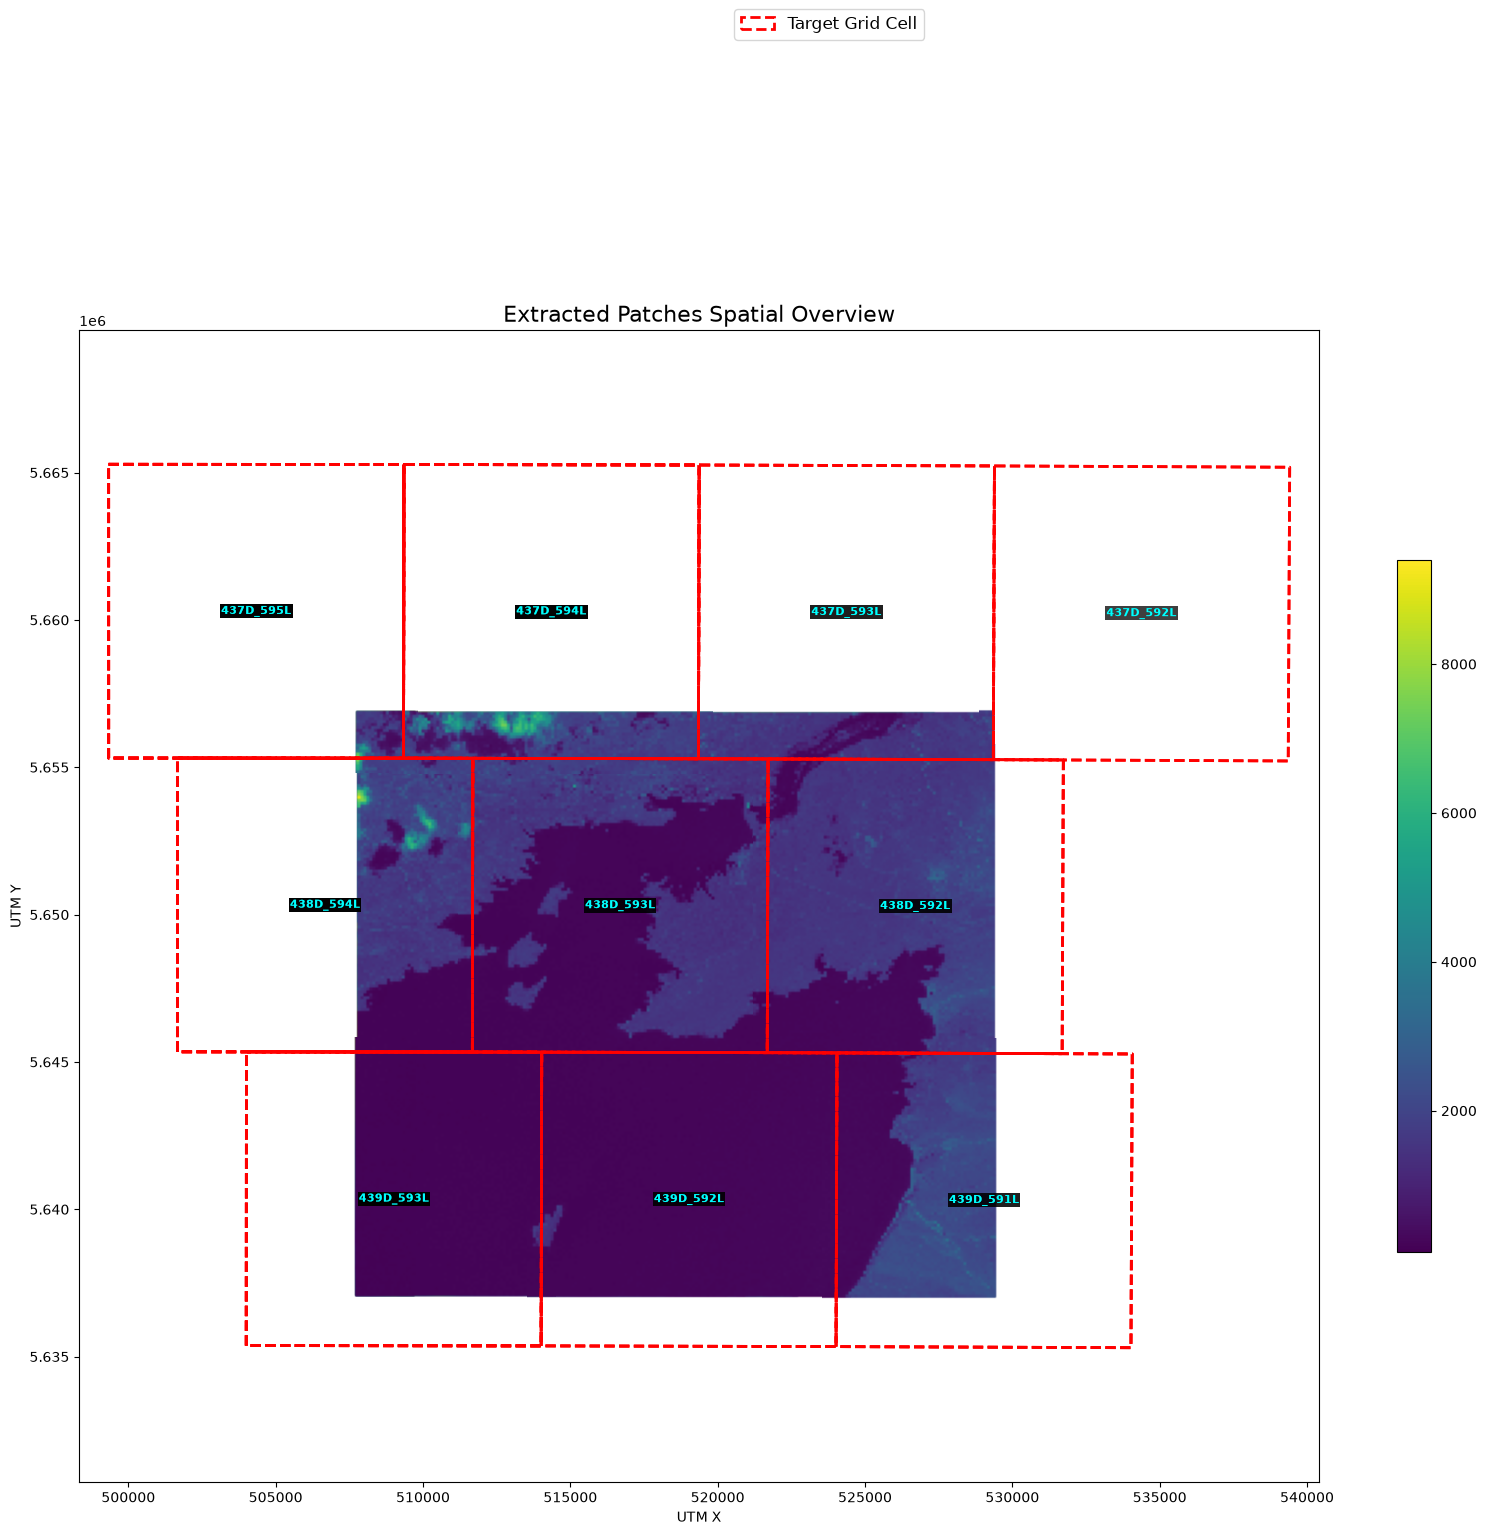

In [12]:
from aereo.viz import plot_artifact_patches

plot_artifact_patches(artifacts, ds_factor=10, cmap="viridis")